# 03 — The structural hierarchy, on a complete census

Notebook 02 predicts an order in which cycle structure should surface in the
embedding: triangles first (they enter at second order with the dominant
coefficient), then four-cycles and diamonds (same order, smaller
coefficients), then five- and six-cycles (third-order, three-root
structure). This notebook tests that prediction on the **complete population
of connected cubic graphs at $n = 14$** — all 509 of them, no sampling — with
three instruments of decreasing indirectness:

1. **Global geometry.** Does embedding distance track triangle differences?
2. **Conditional geometry.** Fix the triangle count; does $C_4$ become the
   organizing direction? Fix $(C_3, C_4)$; what about $C_5$?
3. **Linear accessibility.** Can a held-out ridge probe *read out* each cycle
   count, and how does its performance decay with cycle length?

Instruments 1–2 measure whether the geometry is *organized* by a quantity;
instrument 3 measures whether a fixed linear protocol can *extract* it. Those
are different questions with different answers, and conflating them is the
main way results like these get overstated.

Everything is regenerated in this notebook: census (nauty-geng), cycle
counts (validated against trace identities in `quic.selfcheck`), exact
embeddings, statistics. Runtime is about a minute.


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import quic
from quic import theory  # noqa: F401  (used by later notebooks)

# Consistent, colorblind-safe styling across the notebook series (Okabe-Ito).
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
         "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9",
         "black": "#000000"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10.5, "axes.titlesize": 11.5, "figure.constrained_layout.use": True,
})

report = quic.selfcheck()


selfcheck passed: 14 check groups, worst qiskit/numpy disagreement 2.78e-16


In [2]:
import time

from scipy import stats
from scipy.spatial.distance import pdist, squareform

from quic import circuit_probabilities
from quic.datasets import cubic_census
from quic.finite_shots import ridge_probe_r2
from quic.graph_features import cycle_counts
from quic.readouts import readout_R0

t0 = time.time()
graphs, g6 = cubic_census(14)
EMB = np.vstack([readout_R0(circuit_probabilities(nx.to_numpy_array(g)))
                 for g in graphs])
counts = [cycle_counts(g, max_len=6) for g in graphs]
CYC = {k: np.array([c[k] for c in counts], dtype=float) for k in (3, 4, 5, 6)}
print(f"{len(graphs)} graphs, embeddings {EMB.shape}, "
      f"C3 range {int(CYC[3].min())}..{int(CYC[3].max())}  "
      f"[{time.time()-t0:.0f}s]")

509 graphs, embeddings (509, 16384), C3 range 0..6  [3s]


## 0. The mechanism controls come first

Before attributing anything to graph structure: two ablated circuits run on a
subset of the census. Removing the entangler (`no-edge`) or removing the
mixer (`no-mixer`) must produce **graph-blind** embeddings — on a regular
census the encoder alone carries no graph information, and the entangler
without a mixer is measurement-invisible phase. Across-graph standard
deviation at machine zero confirms that everything measured below is the
incremental effect of the *noncommuting combination* of the two layers.


In [3]:
subset = list(range(0, 509, 9))     # 57 graphs, evenly spaced in census order
for name, spec in quic.circuits.CONTROL_SPECS.items():
    control_emb = np.vstack([
        readout_R0(circuit_probabilities(nx.to_numpy_array(graphs[i]), **spec))
        for i in subset])
    spread = float(control_emb.std(axis=0).max())
    print(f"{name:9s} control: max across-graph SD = {spread:.2e}  (graph-blind)")
    assert spread < 1e-12

no-edge   control: max across-graph SD = 2.22e-16  (graph-blind)
no-mixer  control: max across-graph SD = 5.55e-16  (graph-blind)


## 1. Global geometry: triangles dominate

Pairwise $\ell_1$ embedding distances against triangle-count differences,
over all $\binom{509}{2} = 129{,}286$ pairs, with a Mantel-style permutation
test (graph labels permuted, correlation recomputed) for significance.


In [4]:
D_emb = pdist(EMB, metric="cityblock")
d_c3 = pdist(CYC[3][:, None], metric="cityblock")
r_global = stats.pearsonr(D_emb, d_c3)[0]

# Mantel permutation: permute graph identities, recompute the correlation.
rng = np.random.default_rng(0)
D_sq = squareform(D_emb).astype(np.float32)
iu = np.triu_indices(len(graphs), k=1)
null_r = np.empty(1000)
d_c3_centered = d_c3 - d_c3.mean()
denom_c3 = np.sqrt((d_c3_centered ** 2).sum())
for t in range(1000):
    p = rng.permutation(len(graphs))
    Dp = D_sq[np.ix_(p, p)][iu]
    Dp_c = Dp - Dp.mean()
    null_r[t] = float((Dp_c @ d_c3_centered) / (np.sqrt((Dp_c ** 2).sum()) * denom_c3))
p_mantel = (1 + np.sum(null_r >= r_global)) / (1 + len(null_r))
print(f"Mantel r(embedding distance, |dC3|) = {r_global:.3f}, "
      f"permutation p < {p_mantel:.3f}  (null max {null_r.max():.3f})")

Mantel r(embedding distance, |dC3|) = 0.933, permutation p < 0.001  (null max 0.065)


## 2. Conditional geometry: the next cycle takes over

The layered claim is not "triangles correlate" — it is that after
conditioning on triangles, the *next* motif organizes the residual geometry.
Within each fixed-$C_3$ stratum, the Mantel correlation is recomputed against
$|\Delta C_4|$; within each fixed-$(C_3, C_4)$ stratum (size $\ge 15$),
against $|\Delta C_5|$.


In [5]:
def mantel_within(indices, target_values):
    d = pdist(EMB[indices], metric="cityblock")
    dt = pdist(target_values[indices, None], metric="cityblock")
    if dt.std() == 0:
        return np.nan
    return stats.pearsonr(d, dt)[0]

strata_c3 = {}
for v in sorted(set(CYC[3].astype(int).tolist())):
    idx = np.nonzero(CYC[3] == v)[0]
    if len(idx) >= 12:
        strata_c3[v] = (len(idx), mantel_within(idx, CYC[4]))
print("fixed C3 -> r(distance, |dC4|):")
for v, (size, r) in strata_c3.items():
    print(f"  C3={v} (n={size:3d}): r = {r:.3f}")

strata_c34 = {}
for a in sorted(set(CYC[3].astype(int).tolist())):
    for b in sorted(set(CYC[4].astype(int).tolist())):
        idx = np.nonzero((CYC[3] == a) & (CYC[4] == b))[0]
        if len(idx) >= 15:
            strata_c34[(a, b)] = (len(idx), mantel_within(idx, CYC[5]))
sizes = np.array([s for s, _ in strata_c34.values()])
rs = np.array([r for _, r in strata_c34.values()])
weighted_mean_r5 = float((sizes * rs).sum() / sizes.sum())
print(f"\nfixed (C3, C4) -> r(distance, |dC5|) over {len(strata_c34)} strata:")
for (a, b), (size, r) in strata_c34.items():
    print(f"  (C3,C4)=({a},{b}) (n={size:2d}): r = {r:+.3f}")
print(f"  size-weighted mean r = {weighted_mean_r5:.3f}, "
      f"range [{rs.min():+.3f}, {rs.max():+.3f}]")

fixed C3 -> r(distance, |dC4|):
  C3=0 (n=110): r = 0.981
  C3=1 (n=122): r = 0.979
  C3=2 (n=139): r = 0.957
  C3=3 (n= 74): r = 0.949
  C3=4 (n= 45): r = 0.948
  C3=5 (n= 12): r = 0.938

fixed (C3, C4) -> r(distance, |dC5|) over 12 strata:
  (C3,C4)=(0,2) (n=24): r = +0.924
  (C3,C4)=(0,3) (n=20): r = +0.347
  (C3,C4)=(0,4) (n=18): r = +0.189
  (C3,C4)=(1,1) (n=21): r = +0.910
  (C3,C4)=(1,2) (n=33): r = +0.928
  (C3,C4)=(1,3) (n=25): r = +0.112
  (C3,C4)=(1,4) (n=19): r = +0.127
  (C3,C4)=(2,1) (n=26): r = +0.757
  (C3,C4)=(2,2) (n=32): r = +0.414
  (C3,C4)=(2,3) (n=34): r = +0.188
  (C3,C4)=(2,4) (n=16): r = +0.142
  (C3,C4)=(3,2) (n=20): r = +0.116
  size-weighted mean r = 0.456, range [+0.112, +0.928]


## 3. Linear accessibility: what a frozen probe can read out

Held-out $R^2$ of a ridge probe (5-fold, $\alpha$ selected inside each
training fold by leave-one-out GCV over a wide grid) for each cycle count
from the full sorted embedding, plus a shuffled-target control run under the
identical protocol.

A probe failure is evidence about the *protocol*, not proof the information
is absent — notebook 02 shows $C_5$ and $C_6$ present in ideal first-order
score histograms that global sorting then pools. The honest summary is the
pair: geometry organized (section 2) *and* readout progressively harder with
cycle length.


In [6]:
probe_r2 = {f"C{k}": ridge_probe_r2(EMB, CYC[k]) for k in (3, 4, 5, 6)}
rng = np.random.default_rng(1)
probe_r2["C3 shuffled"] = ridge_probe_r2(EMB, rng.permutation(CYC[3]))
for name, value in probe_r2.items():
    print(f"held-out R2, {name:12s}: {value:+.4f}")
assert probe_r2["C3"] > 0.999 and probe_r2["C3 shuffled"] < 0.05
assert probe_r2["C3"] > probe_r2["C4"] > probe_r2["C5"] > probe_r2["C6"]

held-out R2, C3          : +1.0000
held-out R2, C4          : +0.9970
held-out R2, C5          : +0.8940
held-out R2, C6          : +0.3367
held-out R2, C3 shuffled : -0.0145


## The hierarchy, in one figure

$$
C_3 \;\longrightarrow\; C_4 \;\longrightarrow\; C_5\ (\to C_6)
$$

Panel (a): global geometry is triangle-dominated. Panel (b): with triangles
fixed, four-cycles organize every stratum nearly as strongly. Panel (c): with
both fixed, five-cycles still organize most strata, unevenly — the hierarchy
weakens with depth rather than switching off. Panel (d): linear readout
decays monotonically with cycle length while the shuffled control sits at
zero; $C_6$ is included as the notebook's *weakest* result, not hidden.


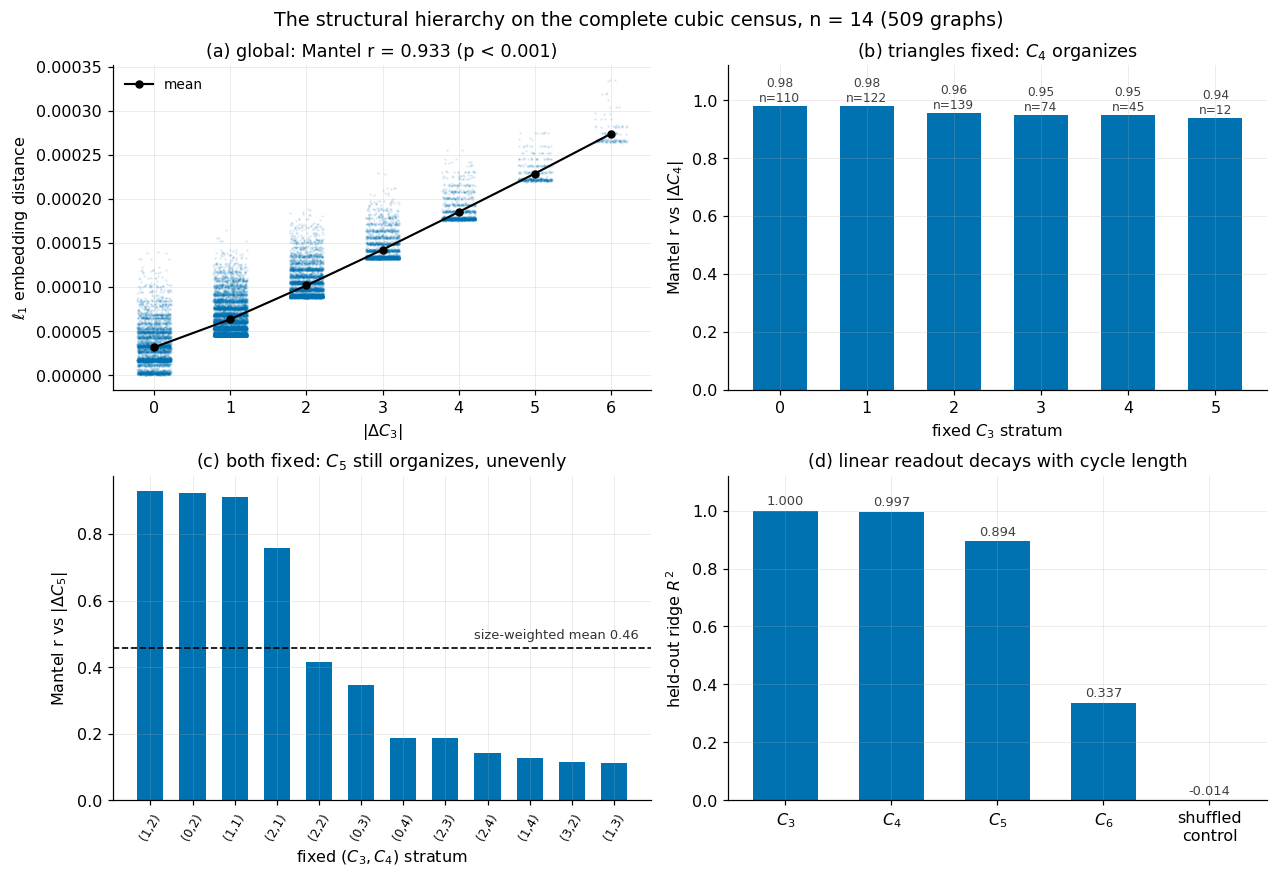

In [7]:
import os

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6))
BLUE = OKABE["blue"]

# (a) distance vs |dC3| (subsampled strips + means)
ax = axes[0, 0]
sub = rng.choice(len(D_emb), 25000, replace=False)
jitter = rng.uniform(-0.22, 0.22, len(sub))
ax.plot(d_c3[sub] + jitter, D_emb[sub], ".", markersize=1.4, alpha=0.10,
        color=BLUE, rasterized=True)
means = [D_emb[d_c3 == v].mean() for v in np.unique(d_c3)]
ax.plot(np.unique(d_c3), means, "o-", color=OKABE["black"], markersize=4.5,
        linewidth=1.4, label="mean")
ax.set_xlabel("$|\\Delta C_3|$")
ax.set_ylabel("$\\ell_1$ embedding distance")
ax.set_title(f"(a) global: Mantel r = {r_global:.3f} (p < 0.001)")
ax.legend(frameon=False, fontsize=9)

# (b) fixed-C3 strata: C4 correlation
ax = axes[0, 1]
xs = list(strata_c3)
rs_b = [strata_c3[v][1] for v in xs]
ax.bar(xs, rs_b, color=BLUE, width=0.62)
for v, r in zip(xs, rs_b):
    ax.text(v, r + 0.015, f"{r:.2f}\nn={strata_c3[v][0]}", ha="center",
            fontsize=8, color="0.25")
ax.set_ylim(0, 1.12)
ax.set_xlabel("fixed $C_3$ stratum")
ax.set_ylabel("Mantel r vs $|\\Delta C_4|$")
ax.set_title("(b) triangles fixed: $C_4$ organizes")

# (c) fixed-(C3,C4) strata: C5 correlation
ax = axes[1, 0]
labels = [f"({a},{b})" for a, b in strata_c34]
vals = [strata_c34[k][1] for k in strata_c34]
order = np.argsort(vals)[::-1]
ax.bar(np.arange(len(vals)), np.array(vals)[order], color=BLUE, width=0.62)
ax.axhline(weighted_mean_r5, color=OKABE["black"], linewidth=1.1,
           linestyle="--")
ax.annotate(f"size-weighted mean {weighted_mean_r5:.2f}",
            (len(vals) - 0.4, weighted_mean_r5 + 0.03), fontsize=8.5,
            ha="right", color="0.2")
ax.set_xticks(np.arange(len(vals)),
              [labels[i] for i in order], rotation=60, fontsize=8)
ax.set_xlabel("fixed $(C_3, C_4)$ stratum")
ax.set_ylabel("Mantel r vs $|\\Delta C_5|$")
ax.set_title("(c) both fixed: $C_5$ still organizes, unevenly")

# (d) probe R2 by motif
ax = axes[1, 1]
names = ["C3", "C4", "C5", "C6", "C3 shuffled"]
colors = [BLUE] * 4 + ["0.65"]
vals = [max(probe_r2[n], 0) for n in names]
ax.bar(np.arange(5), vals, color=colors, width=0.62)
for i, n in enumerate(names):
    ax.text(i, vals[i] + 0.02, f"{probe_r2[n]:.3f}", ha="center", fontsize=8.5,
            color="0.25")
ax.set_ylim(0, 1.12)
ax.set_xticks(np.arange(5), ["$C_3$", "$C_4$", "$C_5$", "$C_6$", "shuffled\ncontrol"])
ax.set_ylabel("held-out ridge $R^2$")
ax.set_title("(d) linear readout decays with cycle length")

fig.suptitle("The structural hierarchy on the complete cubic census, n = 14 "
             "(509 graphs)", y=1.03, fontsize=12.5)
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/structural_hierarchy.png")
plt.show()

## Scope and limitations

All statements are population statements about the complete connected cubic
census at $n = 14$ at the canonical operating point — exhaustive within
scope, and *only* within scope. Regularity is doing real work: the degree
encoder is uniform here by construction, so everything measured is entangler
structure (the controls in section 0 make that explicit), and none of it
transfers unchanged to irregular graphs — notebook 05 shows the degree
dimension changes the readout question entirely. The Mantel correlations
measure organization of the geometry, not decodability; the ridge probe
measures decodability under one frozen linear protocol, not information
content. $C_6$ is reported as the weakest linear target rather than
excluded. Cross-order transfer (does the profile reorder at $n = 12$ or on
4-regular censuses?) is not tested here.

Notebook 04 already showed the *other* boundary of what cycle counts explain:
exactly-cospectral pairs tie on every $C_3..C_7$ yet remain separated — the
embedding holds more than the cycle table. Notebook 05 turns to what any of
this costs to *measure*.
